In [3]:
# Importamos la lógica abstraída en nuestro módulo core
from src.ml_core import (preparar_datos, entrenar_modelos, evaluar_modelos, 
                         mostrar_matriz_confusion, generar_proyeccion_negocio)

import pandas as pd
import warnings
warnings.filterwarnings('ignore')

In [4]:
# FASES 1, 2 y 3: Preprocesamiento y SMOTE automatizados
ruta_datos = 'data/Base_clientes_Monopoly.xlsx'
X_train_res, y_train_res, X_test_prep, y_test, preprocessor, df_original, indices_test = preparar_datos(ruta_datos)

print(f"Datos preparados. X_train balanceado: {X_train_res.shape}")

Datos preparados. X_train balanceado: (74438, 609)


In [7]:
# FASE 4 y 5: Entrenamiento y Evaluación
modelos = entrenar_modelos(X_train_res, y_train_res)
df_metricas = evaluar_modelos(modelos, X_test_prep, y_test)

display(df_metricas.style.highlight_max(color='green'))

,Accuracy,Precision,Recall,F1-Score
Modelo,,,,
Regresión Logística,0.878044,0.414799,0.865217,0.560761
Random Forest,0.929095,0.633015,0.504348,0.561404
XGBoost,0.929682,0.642150,0.493478,0.558082


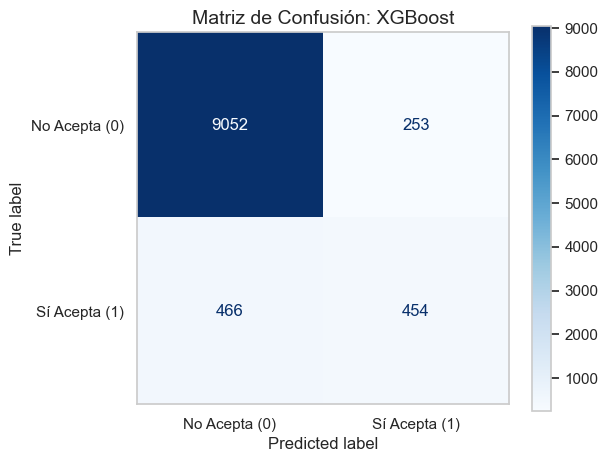

In [8]:
# Supongamos que XGBoost fue el ganador por sus métricas
modelo_ganador = modelos['XGBoost']

# Generar Matriz
mostrar_matriz_confusion(modelo_ganador, X_test_prep, y_test, 'XGBoost')

In [9]:
# FASE 6: Identificación de clientes para el equipo de ventas
potenciales_clientes = generar_proyeccion_negocio(
    modelo_final=modelo_ganador, 
    preprocessor=preprocessor, 
    df_original=df_original, 
    X_test_prep=X_test_prep, 
    indices_test=indices_test
)

print(f"De los {len(y_test)} clientes en la prueba, el modelo identificó {len(potenciales_clientes)} con alta probabilidad de compra.")
print("Top 5 clientes para campaña de marketing inmediata:")
display(potenciales_clientes[['Id', 'Probabilidad_Aceptacion']].head())

De los 10225 clientes en la prueba, el modelo identificó 707 con alta probabilidad de compra.
Top 5 clientes para campaña de marketing inmediata:


,Id,Probabilidad_Aceptacion
44972,44973,0.988688
39698,39699,0.983810
41250,41251,0.981930
45335,45336,0.978449
36944,36945,0.975419
